In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


1) Data Exploration: 

In [2]:
# loading the dataset
df = pd.read_csv('diabetes.csv') 

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
#EDA
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
#EDA
df.shape

(768, 9)

In [6]:
#EDA
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

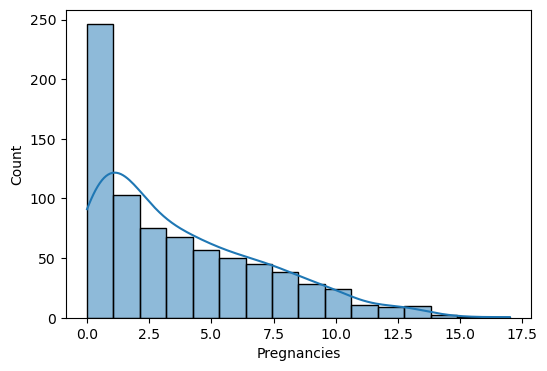

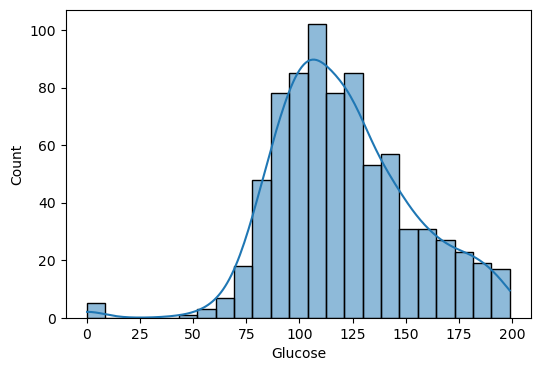

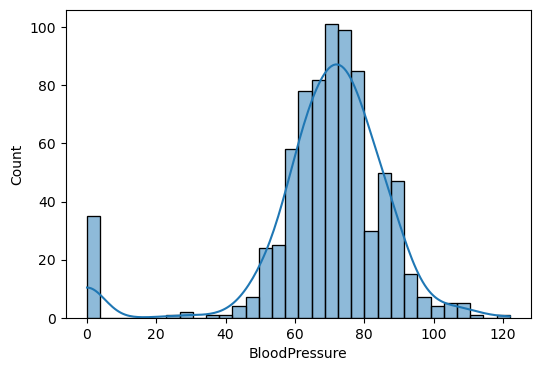

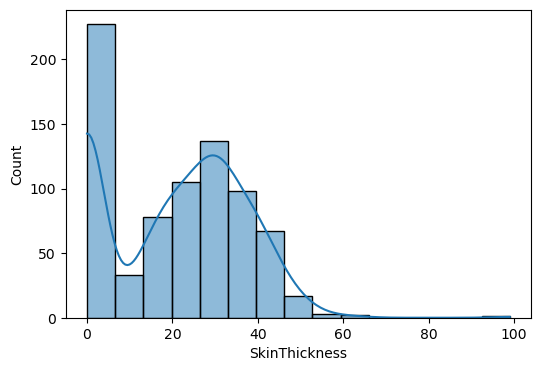

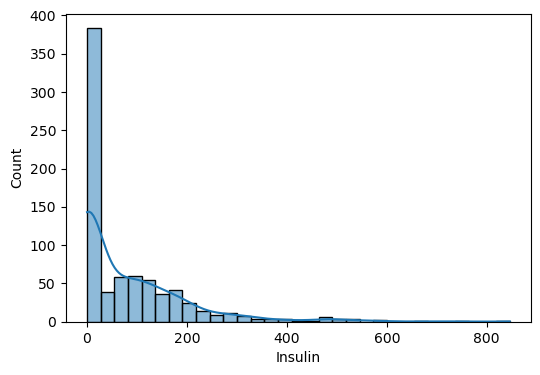

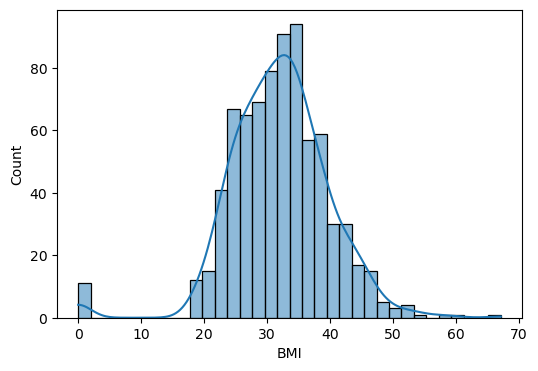

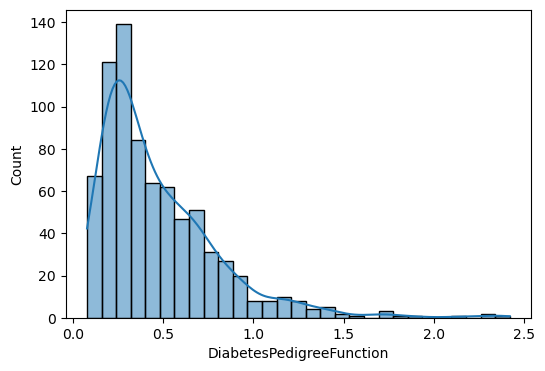

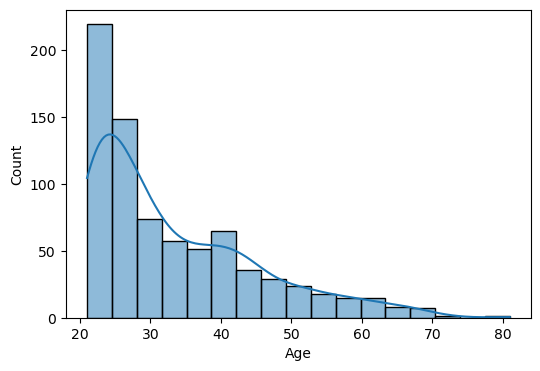

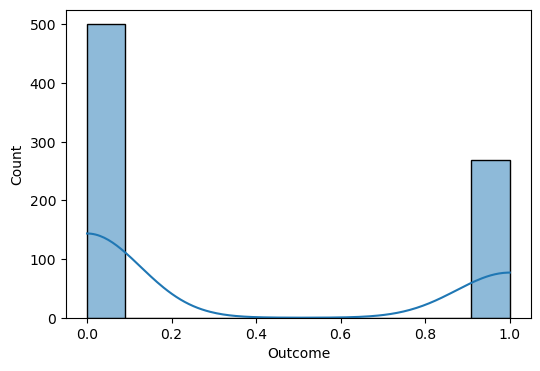

In [8]:
# Data  visualizations for hist plot 

col = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

for i in col :
    plt.figure(figsize=(6,4))
    sns.histplot(df[i],kde=True)

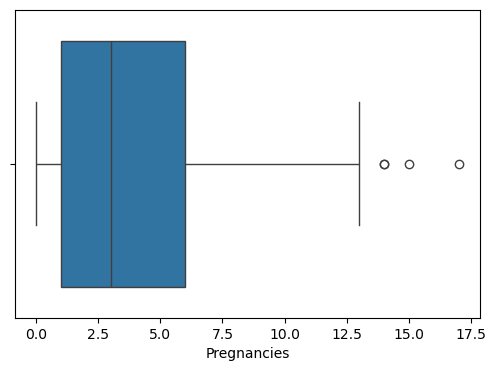

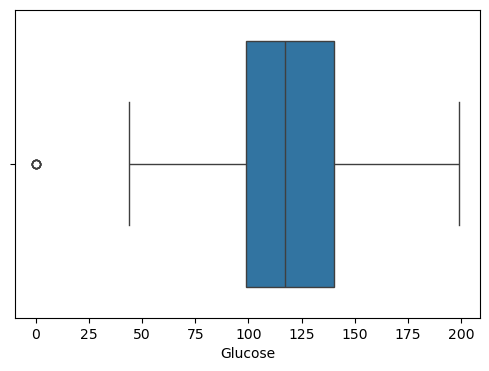

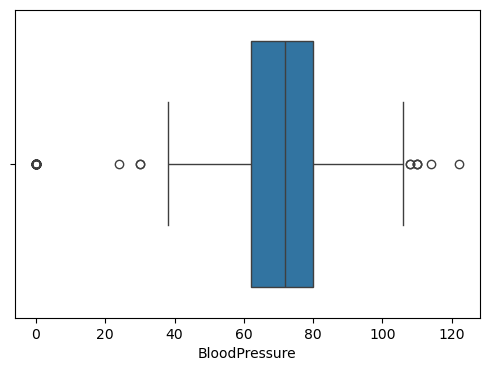

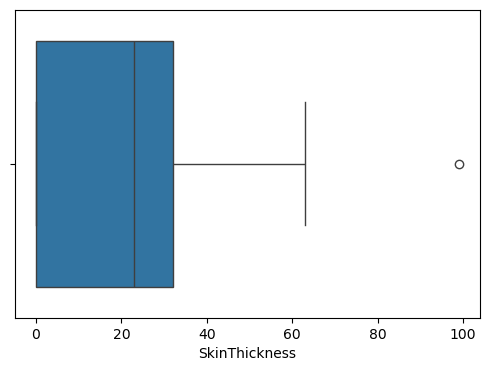

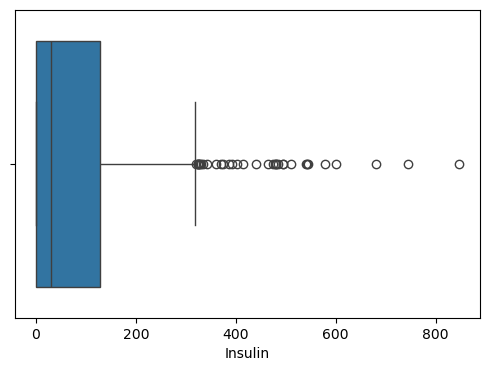

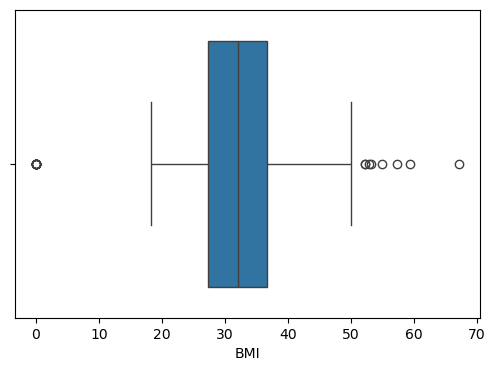

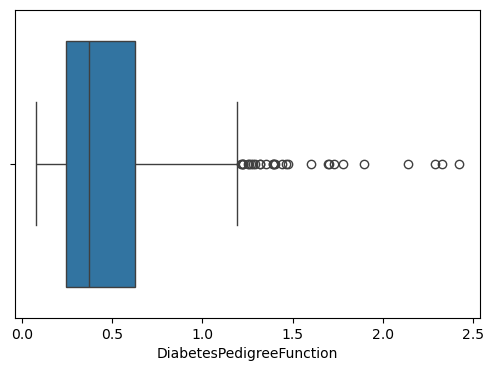

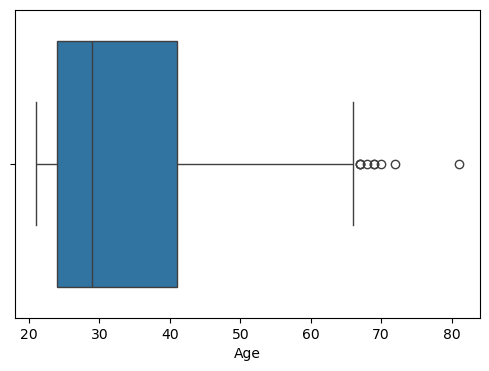

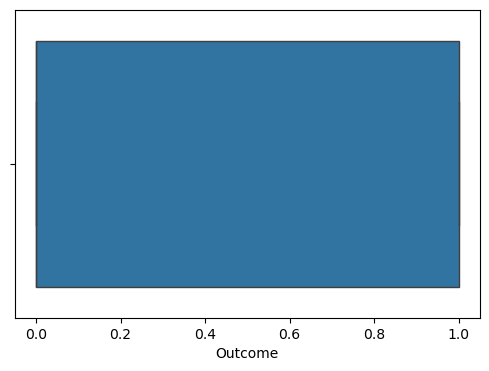

In [9]:
for i in col :
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[i])

In [10]:
# dropping the outcome column
X = df.drop(['Outcome'],axis=1)

In [11]:
Y = df['Outcome']

In [12]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [13]:
Y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [14]:
# importing the train, test, split
from sklearn.model_selection import train_test_split

#### 3) Model Building: 

In [15]:
x_train,x_test,y_train,y_test = train_test_split(X,Y, test_size = 0.2, random_state = 42)

In [16]:
# importing model
from sklearn.linear_model import LogisticRegression

In [17]:
model= LogisticRegression()

In [18]:
# training the model
model.fit(x_train,y_train)

C:\Users\Lenovo\python_practise\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [19]:
from sklearn.metrics import classification_report, confusion_matrix,roc_curve,roc_auc_score

#### 4) Model Evaluation:

In [20]:
y_pred = model.predict(x_test)

In [21]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [22]:
confusion_matrix(y_test,y_pred)

array([[78, 21],
       [18, 37]])

In [23]:
y_pred_prob = model.predict_proba(x_test)

In [24]:
fpr,tpr,threshold = roc_curve(y_test,y_pred)

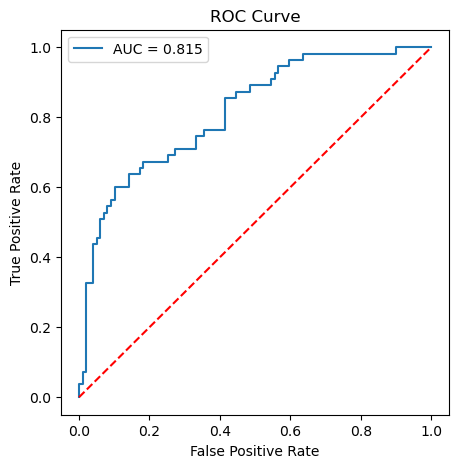

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities of class 1
y_pred_prob = model.predict_proba(x_test)

# ROC values
fpr, tpr, threshold = roc_curve(y_test, y_pred_prob[:,1])

# AUC
auc = roc_auc_score(y_test, y_pred_prob[:,1])

# Plot
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'r--')  # Random model

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [26]:
import joblib
joblib.dump(model,'logistics.pkl')

['logistics.pkl']

In [27]:
!pip install streamlit

In [28]:
import sys
print(sys.executable)

C:\Users\Lenovo\python_practise\python.exe


In [29]:
import streamlit
print(streamlit.__version__)

1.51.0


In [30]:
import streamlit as st
import pandas as pd
import joblib

In [31]:
dt= joblib.load("logistics.pkl")
st.title("Diabetes prediction")


2026-07-23 16:05:02.460 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 16:05:04.101 
  command:

    streamlit run C:\Users\Lenovo\python_practise\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-23 16:05:04.102 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 16:05:04.103 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [32]:
dt

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [33]:
st.write("Model loaded successfully!")

2026-07-23 16:05:04.142 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 16:05:04.143 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 16:05:04.147 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [34]:
import sys
print(sys.executable)

C:\Users\Lenovo\python_practise\python.exe


# 1
## precision is out of all the predicted positive how many are actually positive. Precision=TP/FP+TP​
## recall is out of actual positive how many we predicted.Recall=TP/FN+TP​

# 2

## Cross-validation is a model evaluation technique used to measure how well a machine learning model performs on unseen data
## It provides a more reliable estimate of the model's performance.
## It reduces the risk of overfitting, where the model performs well on training data but poorly on new data.